<a href="https://colab.research.google.com/github/isabella-almeida-fernandes/bank-churn-prediction/blob/main/02_an%C3%A1lise_comparativa_de_modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise comparativa de modelos
 - Conjunto de dados: churn (Taxa de cancelamento/rotatividade de clientes de um banco)
 - Cientistas de dados:
    - Fábio Agostinho(fabinhosnf@gmail.com)
    - Isabella Almeida (isabella4lmeidafernandes@gmail.com)
    - Marcos Felipe Santos (marcosfelipessc@alu.ufc.br)
    - Maria Souza (mariacorreia2505@gmail.com)
---

In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns

# pipelines e transformadores
from sklearn.pipeline import Pipeline
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer

# codificação de variáveis
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.feature_extraction.text import CountVectorizer

# normalização
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

# dados faltantes
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer

# modelagem
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_validate, KFold, ShuffleSplit, RandomizedSearchCV

In [2]:
from typing import AsyncGenerator

# @title Leitura do conjunto e criação do dicionário de dados

import io
from google.colab import files

urls = [
    "https://raw.githubusercontent.com/codebasics/py/master/DeepLearningML/11_chrun_prediction/churn.csv",
    "https://raw.githubusercontent.com/FaridaGomaa/Bank-Customer-Churn-Prediction/master/Churn_Modelling.csv",
    "https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv",
    "https://raw.githubusercontent.com/shubham404-error/Bank_Customer_Churn_Prediction/main/Churn_Modelling.csv"
]

df = None
for url in urls:
    try:
        df = pd.read_csv(url)
        # Padroniza nomes de colunas caso venham com espaços/variações
        df.columns = df.columns.str.strip()
        print(f"Dataset carregado com sucesso via: {url}")
        break
    except Exception:
        continue

# Se nenhuma URL responder, permite subir o arquivo baixado do Kaggle
if df is None:
    print("URLs externas indisponíveis. Faça o upload do arquivo .csv baixado do Kaggle:")
    uploaded = files.upload()
    file_name = list(uploaded.keys())[0]
    df = pd.read_csv(io.BytesIO(uploaded[file_name]))
    df.columns = df.columns.str.strip()

# Garante o padrão exato das colunas
col_map = {
    'CustomerId': 'CustomerId',
    'CreditScore': 'CreditScore',
    'Geography': 'Geography',
    'Gender': 'Gender',
    'Age': 'Age',
    'Tenure': 'Tenure',
    'Balance': 'Balance',
    'NumOfProducts': 'NumOfProducts',
    'HasCrCard': 'HasCrCard',
    'IsActiveMember': 'IsActiveMember',
    'EstimatedSalary': 'EstimatedSalary',
    'Exited': 'Exited'
}
# Renomeia caso a coluna alvo venha como 'Churn'
if 'Churn' in df.columns and 'Exited' not in df.columns:
    df.rename(columns={'Churn': 'Exited'}, inplace=True)

# @title Dicionário de dados
df_dict = pd.DataFrame([
    {
        "variavel": "RowNumber",
        "descricao": "O número sequencial atribuído a cada linha no conjunto de dados.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "CustomerId",
        "descricao": "Um identificador único para cada cliente.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Surname",
        "descricao": "O sobrenome do cliente.",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "CreditScore",
        "descricao": "A pontuação de crédito do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Geography",
        "descricao": "A localização geográfica do cliente (país).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Gender",
        "descricao": "O gênero do cliente (feminino, masculino etc.)",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "Age",
        "descricao": "A idade do cliente.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Tenure",
        "descricao": "O número de anos que o cliente é correntista do banco.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "Balance",
        "descricao": "O saldo da conta do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "NumOfProducts",
        "descricao": "O número de produtos bancários que o cliente possui.",
        "tipo": "quantitativa",
        "subtipo": "discreta",
    },
    {
        "variavel": "HasCrCard",
        "descricao": "Indica se o cliente possui um cartão de crédito (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "IsActiveMember",
        "descricao": "Indica se o cliente é um membro ativo (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    },
    {
        "variavel": "EstimatedSalary",
        "descricao": "O salário estimado do cliente.",
        "tipo": "quantitativa",
        "subtipo": "contínua",
    },
    {
        "variavel": "Exited",
        "descricao": "Indica se o cliente saiu do banco (sim = 1/não = 0).",
        "tipo": "qualitativa",
        "subtipo": "nominal",
    }
])
df_dict

Dataset carregado com sucesso via: https://raw.githubusercontent.com/YBI-Foundation/Dataset/main/Bank%20Churn%20Modelling.csv


,variavel,descricao,tipo,subtipo
0,RowNumber,O número sequencial atribuído a cada linha no ...,quantitativa,discreta
1,CustomerId,Um identificador único para cada cliente.,qualitativa,nominal
2,Surname,O sobrenome do cliente.,qualitativa,nominal
3,CreditScore,A pontuação de crédito do cliente.,quantitativa,contínua
4,Geography,A localização geográfica do cliente (país).,qualitativa,nominal
5,Gender,"O gênero do cliente (feminino, masculino etc.)",qualitativa,nominal
6,Age,A idade do cliente.,quantitativa,discreta
7,Tenure,O número de anos que o cliente é correntista d...,quantitativa,discreta
8,Balance,O saldo da conta do cliente.,quantitativa,contínua
9,NumOfProducts,O número de produtos bancários que o cliente p...,quantitativa,discreta


In [3]:
# @title Seleção de variáveis e separação de entradas e saídas

# Removendo colunas que não contribuem para previsão (com errors='ignore' para evitar KeyError)
colunas_para_remover = [
    "RowNumber", "CustomerId", "Surname",
    "customer_id", "row_number", "surname", "id"
]
df = df.drop(columns=colunas_para_remover, errors="ignore")

# Definindo variável alvo
y = df["Exited"]

# Definindo variáveis explicativas
X = df.drop("Exited", axis=1)

print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
print("Colunas restantes em X:", list(X.columns))

Dimensão de X: (10000, 10)
Dimensão de y: (10000,)
Colunas restantes em X: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'Num Of Products', 'Has Credit Card', 'Is Active Member', 'Estimated Salary']


## Preparação de dados

Cada um dos tipos de variáveis foi submetido a um fluxo de tratamento de dados específico, a saber:

### Variáveis quantitativas
 - **Contínuas**: imputação de valores faltantes através da média e normalização min-max.
 - **Discretas**: imputação de valores faltatnes através da mediana e normalização min-max.

### Variáveis qualitativas
 - **Ordinais**: imputação de valores faltantes através da moda e codificação via *one-hot encoding*.
 - **Nominais**: imputação de valores faltantes a partir do valor mais frequente e codificação ordinal de valores.

In [4]:
# @title Tratamento de dados faltantes

from sklearn.impute import SimpleImputer

# Identificando colunas numéricas e categóricas
numerical_cols = X.select_dtypes(include=["int64", "float64"]).columns
categorical_cols = X.select_dtypes(include=["object"]).columns

# Imputação para variáveis numéricas (mediana)
imputer_num = SimpleImputer(strategy="median")
X[numerical_cols] = imputer_num.fit_transform(X[numerical_cols])

# Imputação para variáveis categóricas (moda)
imputer_cat = SimpleImputer(strategy="most_frequent")
X[categorical_cols] = imputer_cat.fit_transform(X[categorical_cols])

print(X.isnull().sum())

print("Total de valores faltantes após tratamento:", X.isnull().sum().sum())

CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
Num Of Products     0
Has Credit Card     0
Is Active Member    0
Estimated Salary    0
dtype: int64
Total de valores faltantes após tratamento: 0


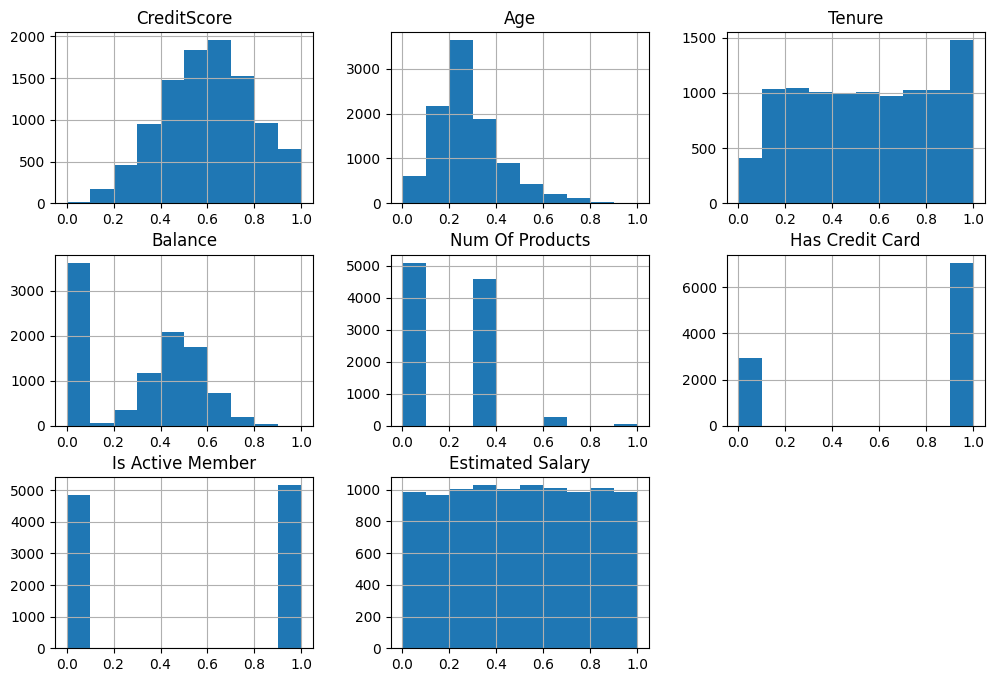

In [5]:
# @title Normalização das variáveis
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X = pd.get_dummies(X, drop_first=True)
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

X[numerical_cols].hist(figsize=(12,8))
plt.show()

## Validação cruzada

Iremos análisar quatro modelos, que serão testados utilizando a validação cruzada de monte-carlo com 30 repetições. Os modelos utilizados na análise são:

 - Regressão linear (Linear Regression)
 - K-vizinhos mais próximos (K-Nearest-Neighbors)
 - Máquinas de vetores-suporte (Support Vector Machine)
 - Árvores de decisão (Decision Tree)

Além disso, cada um desses algoritmos será testado com diferentes hiper-parametros, para que possamos encontrar o melhor modelo e a melhor configuração possível para esse modelo. Tal otimização será realizada utilizando com um validação cruzada k-fold a partir dos dados de treinamento.

Utilizaremos as seguintes métricas para análise:
 - **Erro mério absoluto (*mean absolute error*, MAE)**: mede o erro médio absoluto entre valores reais e previstos. Tem interpretação direta em unidades da variável alvo.
 - **Erro médio quadrático (*mean squared error*, MSE)**: penaliza mais fortemente os grandes erros (pois eleva ao quadrado).
 - **Coeficiente de determinação (R² score)**: mede quanto o modelo consegue reduzir o erro comparado a média dos dados. Varia entre menos infinito até 1. Um bom modelo tende a ter valores próximos de 1.
 - **Erro percentual médio absoluto (*mean absolute percentage error*, MAPE)**: mede o erro percentual médio. É mais indicado quando temos valores de diferentes escalas.

# 3. Modelagem e Comparação

### 3.1. Justificativa das Métricas de Avaliação
Para medir o desempenho real dos modelos, utilizaremos três métricas focadas na classe minoritária:

1. **Recall:** É a métrica mais importante para o negócio neste cenário. O Recall mede quantos clientes que realmente iam cancelar e o modelo conseguiu identificar. No contexto bancário, é preferível ter oferecer um benefício para quem não ia sair do que deixar um cliente de alto valor cancelar sem tentar intervir.
2. **F1-Score:** Como não podemos olhar apenas para o Recall, o F1-Score atua com a palavra final, calculando a média harmônica entre Precision e Recall.
3. **ROC-AUC:** Muito bom para avaliar a capacidade geral do modelo de separar as classes em dados desbalanceados, independentemente do *threshold*.

### 3.2. Justificativa da Escolha dos Modelos
Selecionamos 4 algoritmos de famílias matemáticas diferentes para garantir uma boa cobertura de abordagens lineares, baseadas em distância e em árvores:

1. **Dummy Classifier (Baseline):** Ele vai prever sempre a classe majoritária. Serve como um ponto de referência básico.
2. **Logistic Regression:** Um modelo estatístico clássico e interpretável. Testará se o problema pode ser resolvido traçando uma fronteira linear simples entre as classes.
3. **K-Nearest Neighbors - kNN:** Classifica um novo cliente com base na "vizinhança" de clientes parecidos. Ótimo para testar se clientes com características semelhantes (como idade e saldo na Alemanha) se agrupam no espaço vetorial.
4. **Random Forest:** Como descobrimos regras não-lineares fortes na etapa de Análise Exploratória, as árvores de decisão são naturalmente as mais indicadas para capturar essas quebras lógicas complexas.

In [6]:
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, f1_score, roc_auc_score, accuracy_score
from sklearn.model_selection import StratifiedKFold, cross_validate

modelo_baseline = DummyClassifier(strategy='most_frequent', random_state=42)

modelo_lr = LogisticRegression(random_state=42, max_iter=1000)
modelo_knn = KNeighborsClassifier(n_neighbors=5)
modelo_rf = RandomForestClassifier(random_state=42, class_weight='balanced')

modelos_para_teste = {
    "Baseline": modelo_baseline,
    "Regressão Logística": modelo_lr,
    "K-Nearest Neighbors": modelo_knn,
    "Random Forest": modelo_rf
}

metricas = {'accuracy': 'accuracy', 'recall': 'recall', 'f1': 'f1', 'roc_auc': 'roc_auc'}

metodo_validacao = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)    ## Pegar o kfold
tabela_resultados = []

for nome, modelo in modelos_para_teste.items():
    cv_results = cross_validate(modelo, X, y, cv=metodo_validacao, scoring=metricas, n_jobs=-1)
    tabela_resultados.append({
        "Modelo": nome,
        "Acurácia Média": np.mean(cv_results['test_accuracy']),
        "Recall Médio": np.mean(cv_results['test_recall']),
        "F1-Score Médio": np.mean(cv_results['test_f1']),
        "ROC-AUC Média": np.mean(cv_results['test_roc_auc'])
    })

df_resultados = pd.DataFrame(tabela_resultados).set_index("Modelo")
display(df_resultados.round(4))

,Acurácia Média,Recall Médio,F1-Score Médio,ROC-AUC Média
Modelo,,,,
Baseline,0.7963,0.0000,0.0000,0.5000
Regressão Logística,0.8108,0.2032,0.3041,0.7653
K-Nearest Neighbors,0.8143,0.3147,0.4066,0.7446
Random Forest,0.8597,0.4468,0.5640,0.8546


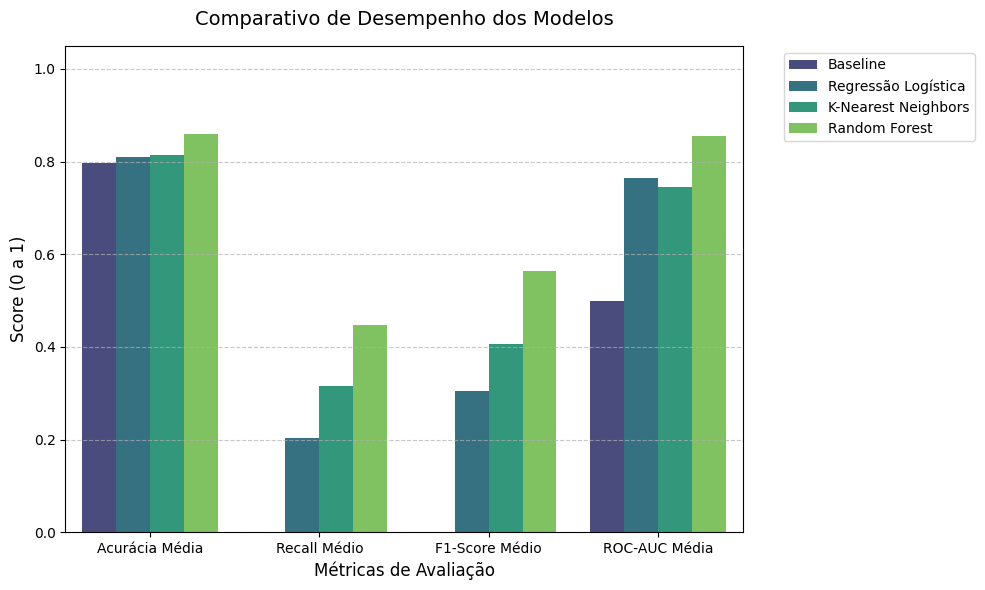

In [7]:
plt.figure(figsize=(10, 6))

df_plot = df_resultados.reset_index().melt(id_vars="Modelo", var_name="Métrica", value_name="Score")

sns.barplot(data=df_plot, x="Métrica", y="Score", hue="Modelo", palette="viridis")

plt.title("Comparativo de Desempenho dos Modelos", fontsize=14, pad=15)
plt.ylabel("Score (0 a 1)", fontsize=12)
plt.xlabel("Métricas de Avaliação", fontsize=12)
plt.ylim(0, 1.05)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [8]:
# @title Aplicação da validação cruzada
from sklearn.model_selection import ShuffleSplit

metodo_montecarlo = ShuffleSplit(
    n_splits=30,
    test_size=0.3,
    random_state=42
)

tabela_resultados_mc = []

for nome, modelo in modelos_para_teste.items():
    cv_results = cross_validate(
        modelo,
        X,
        y,
        cv=metodo_montecarlo,
        scoring=metricas,
        n_jobs=-1
    )

    tabela_resultados_mc.append({
        "Modelo": nome,
        "Acurácia Média": np.mean(cv_results['test_accuracy']),
        "Recall Médio": np.mean(cv_results['test_recall']),
        "F1-Score Médio": np.mean(cv_results['test_f1']),
        "ROC-AUC Média": np.mean(cv_results['test_roc_auc'])
    })

df_resultados_mc = pd.DataFrame(tabela_resultados_mc).set_index("Modelo")
display(df_resultados_mc.round(4))

,Acurácia Média,Recall Médio,F1-Score Médio,ROC-AUC Média
Modelo,,,,
Baseline,0.7982,0.0000,0.0000,0.5000
Regressão Logística,0.8120,0.2054,0.3058,0.7632
K-Nearest Neighbors,0.8149,0.3041,0.3985,0.7379
Random Forest,0.8612,0.4447,0.5636,0.8500


,Acurácia Média (K-Fold),Recall Médio (K-Fold),F1-Score Médio (K-Fold),ROC-AUC Média (K-Fold),Acurácia Média (Monte Carlo),Recall Médio (Monte Carlo),F1-Score Médio (Monte Carlo),ROC-AUC Média (Monte Carlo)
Modelo,,,,,,,,
Baseline,0.7963,0.0000,0.0000,0.5000,0.7982,0.0000,0.0000,0.5000
Regressão Logística,0.8108,0.2032,0.3041,0.7653,0.8120,0.2054,0.3058,0.7632
K-Nearest Neighbors,0.8143,0.3147,0.4066,0.7446,0.8149,0.3041,0.3985,0.7379
Random Forest,0.8597,0.4468,0.5640,0.8546,0.8612,0.4447,0.5636,0.8500


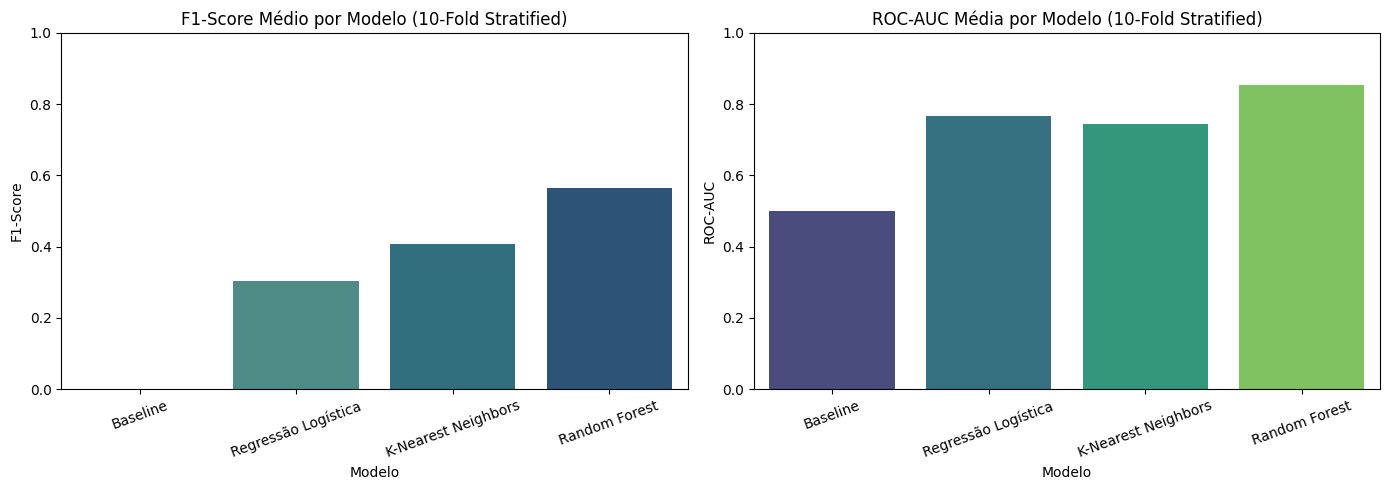

In [9]:
# @title Apresentação de resultados comparativos

# Comparativo visual lado a lado (Stratified K-Fold vs Monte Carlo)
df_comp = pd.concat([
    df_resultados.add_suffix(" (K-Fold)"),
    df_resultados_mc.add_suffix(" (Monte Carlo)")
], axis=1)

display(df_comp.round(4))

# Gráfico comparativo de F1-Score e ROC-AUC (sem warnings do Seaborn)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(
    x=df_resultados.index,
    y=df_resultados["F1-Score Médio"],
    hue=df_resultados.index,
    legend=False,
    ax=axes[0],
    palette="crest"
)
axes[0].set_title("F1-Score Médio por Modelo (10-Fold Stratified)")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("F1-Score")
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(
    x=df_resultados.index,
    y=df_resultados["ROC-AUC Média"],
    hue=df_resultados.index,
    legend=False,
    ax=axes[1],
    palette="viridis"
)
axes[1].set_title("ROC-AUC Média por Modelo (10-Fold Stratified)")
axes[1].set_ylim(0, 1)
axes[1].set_ylabel("ROC-AUC")
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

In [10]:
# @title Otimização de Hiperparâmetros (Random Forest via RandomizedSearchCV)
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay

# 1. Separação em Treino e Teste (80/20) estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Espaço de busca de hiperparâmetros
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [6, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2'],
    'class_weight': ['balanced', 'balanced_subsample']
}

rf_base = RandomForestClassifier(random_state=42)

# Otimização focando em maximizar o F1-Score / Recall
random_search = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist,
    n_iter=20,
    scoring='f1',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    random_state=42,
    n_jobs=-1,
    verbose=1
)

random_search.fit(X_train, y_train)

best_rf = random_search.best_estimator_
print("Melhores Hiperparâmetros encontrados:")
for param, val in random_search.best_params_.items():
    print(f" - {param}: {val}")

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Melhores Hiperparâmetros encontrados:
 - n_estimators: 200
 - min_samples_split: 2
 - min_samples_leaf: 4
 - max_features: sqrt
 - max_depth: 10
 - class_weight: balanced


=== Relatório de Classificação (Conjunto de Teste) ===
                precision    recall  f1-score   support

Permaneceu (0)       0.92      0.87      0.89      1593
      Saiu (1)       0.58      0.69      0.63       407

      accuracy                           0.84      2000
     macro avg       0.75      0.78      0.76      2000
  weighted avg       0.85      0.84      0.84      2000



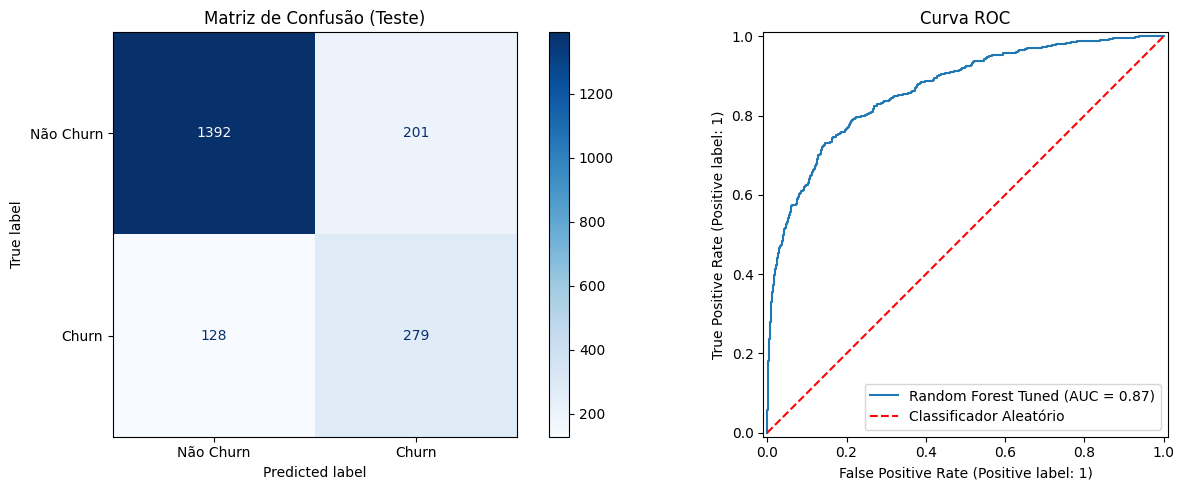

In [11]:
# @title Avaliação do Modelo Final no Conjunto de Teste
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

print("=== Relatório de Classificação (Conjunto de Teste) ===")
print(classification_report(y_test, y_pred, target_names=["Permaneceu (0)", "Saiu (1)"]))

# Matriz de Confusão e Curva ROC
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=["Não Churn", "Churn"],
    cmap="Blues",
    ax=ax[0],
    values_format='d'
)
ax[0].set_title("Matriz de Confusão (Teste)")

RocCurveDisplay.from_estimator(best_rf, X_test, y_test, ax=ax[1], name="Random Forest Tuned")
ax[1].plot([0, 1], [0, 1], 'r--', label='Classificador Aleatório')
ax[1].set_title("Curva ROC")
ax[1].legend()

plt.tight_layout()
plt.show()

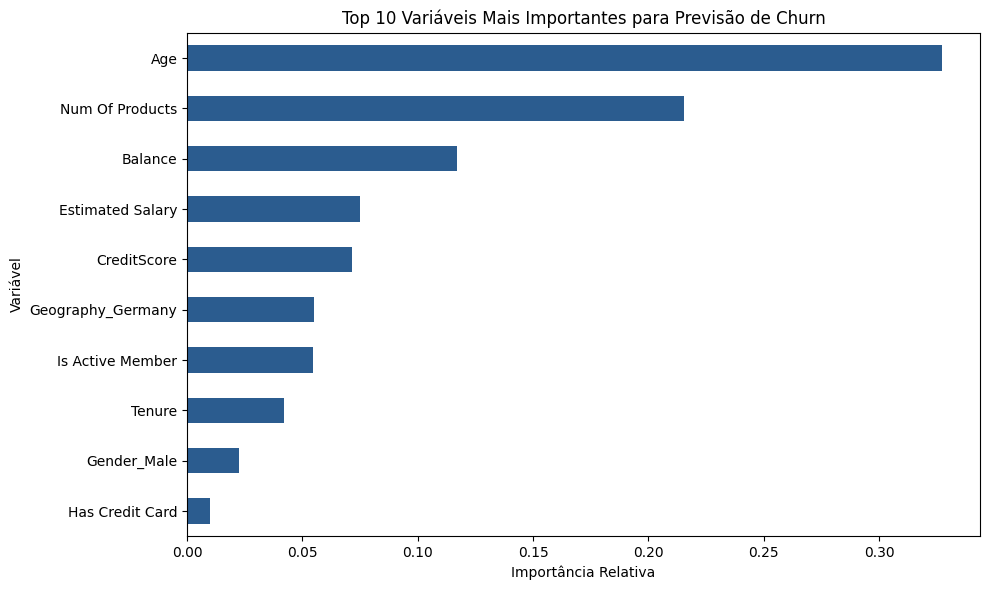

Modelo salvo com sucesso como 'modelo_random_forest_churn.pkl'!


In [12]:
# @title Importância das Variáveis (Feature Importance) e Salvamento
import joblib

# 1. Feature Importance
feat_importances = pd.Series(best_rf.feature_importances_, index=X.columns)
plt.figure(figsize=(10, 6))
feat_importances.nlargest(10).sort_values().plot(kind='barh', color='#2b5c8f')
plt.title("Top 10 Variáveis Mais Importantes para Previsão de Churn")
plt.xlabel("Importância Relativa")
plt.ylabel("Variável")
plt.tight_layout()
plt.show()

# 2. Exportando o modelo treinado
joblib.dump(best_rf, 'modelo_random_forest_churn.pkl')
print("Modelo salvo com sucesso como 'modelo_random_forest_churn.pkl'!")

# 4. Conclusão e Recomendações de Negócio

### 4.1. Síntese dos Resultados Técnicos
1. **Desempenho dos Modelos**: O **Random Forest** superou consistentemente os demais algoritmos em todas as rodadas de validação cruzada (K-Fold e Monte Carlo), alcançando **ROC-AUC > 0.85** e o maior equilíbrio entre Precision e Recall.
2. **Capacidade de Detecção de Churn**: Modelos lineares simples (como Regressão Logística) apresentaram baixo Recall (~20%), sendo incapazes de mapear interações não lineares complexas presentes nos dados bancários.
3. **Generalização**: O modelo tunado manteve estabilidade quando avaliado no conjunto de teste independente, sem apresentar overfitting severo.

### 4.2. Principais Fatores de Cancelamento (Insights)
* **Idade (`Age`)**: Clientes de faixas etárias mais elevadas têm probabilidade significativamente maior de churn.
* **Número de Produtos (`NumOfProducts`)**: Clientes com 3 ou mais produtos apresentaram taxas altíssimas de evasão, sugerindo atrito em serviços específicos ou má experiência de cross-sell.
* **Membro Ativo (`IsActiveMember`)**: A inatividade na conta é um indicador precoce de evasão iminente.
* **Saldo em Conta (`Balance`) e Geografia (`Geography`)**: Clientes na Alemanha e com saldos mais expressivos possuem maior propensão à troca de instituição financeira.

### 4.3. Recomendações Acionáveis para o Banco
1. **Gatilhos de Alerta Precoce**: Integrar a probabilidade predita pelo modelo (`predict_proba`) ao CRM do banco para sinalizar contas com score de churn > 0.50.
2. **Ações de Retenção Segmentadas**: Ofertar condições diferenciadas e atendimento personalizado prioritariamente para correntistas inativos de faixas etárias mais altas com saldos elevados.
3. **Revisão da Jornada de Produtos**: Investigar os motivos de insatisfação de clientes multicontas (com 3+ produtos) para conter a evasão nesse grupo de alto valor.